# T 检验完整教程：从计算到可视化

## 📚 教学目标
1. 理解 T 检验的完整计算步骤
2. 掌握自由度、T 统计量、P 值的概念
3. 可视化 T 分布和显著性检验
4. 理解为什么 P 值要与 0.05 比较

**适用章节**：Python for Data Analysis, 3E - 统计推断部分

## 1. 场景设定：单样本 T 检验

### 🎯 问题
一家食品公司声称其生产的薯片每袋平均重 100g。我们随机抽取了 25 袋薯片，测量重量如下：

**原假设 H₀**：μ = 100g（公司声称正确）
**备择假设 H₁**：μ ≠ 100g（公司声称不正确）

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# 设置随机种子以保证结果可复现
np.random.seed(42)

print("✅ 库导入完成")

✅ 库导入完成


## 2. 生成样本数据

In [2]:
# 生成样本数据：真实Mean为 98g，标准差为 5g
true_mean = 98  # 真实Mean（公司声称的 100g 是错误的）
true_std = 5   # 真实标准差
n = 25         # 样本量
claimed_mean = 100  # 公司声称的Mean

# 生成样本
sample = np.random.normal(true_mean, true_std, n)

# 转换为 DataFrame 方便查看
df = pd.DataFrame({'重量(克)': sample})

print(f"📊 样本数据（前10个）:")
print(df.head(10))
print(f"\n📈 样本基本信息:")
print(f"  样本量 n = {n}")
print(f"  真实Mean = {true_mean}g")
print(f"  公司声称Mean = {claimed_mean}g")

📊 样本数据（前10个）:
        重量(克)
0  100.483571
1   97.308678
2  101.238443
3  105.615149
4   96.829233
5   96.829315
6  105.896064
7  101.837174
8   95.652628
9  100.712800

📈 样本基本信息:
  样本量 n = 25
  真实均值 = 98g
  公司声称均值 = 100g


## 3. T 检验完整计算步骤

### 📐 计算公式

**T 统计量公式**：
$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

其中：
- $\bar{x}$ = 样本均值
- $\mu_0$ = 假设的总体均值（这里是 100g）
- $s$ = 样本标准差
- $n$ = 样本量

**自由度公式**：
$$df = n - 1$$

In [3]:
# ========== 步骤 1: 计算样本Mean ==========
sample_mean = np.mean(sample)
print(f"\n📊 步骤 1: 计算样本Mean")
print(f"  样本Mean x̄ = {sample_mean:.4f} g")
print(f"  计算公式: x̄ = (x₁ + x₂ + ... + xₙ) / n")
print(f"  实际计算: x̄ = {sample.sum():.2f} / {n} = {sample_mean:.4f}")


📊 步骤 1: 计算样本均值
  样本均值 x̄ = 97.1825 g
  计算公式: x̄ = (x₁ + x₂ + ... + xₙ) / n
  实际计算: x̄ = 2429.56 / 25 = 97.1825


In [4]:
# ========== 步骤 2: 计算样本标准差 ==========
sample_std = np.std(sample, ddof=1)  # ddof=1 使用样本标准差（除以 n-1）
print(f"\n📊 步骤 2: 计算样本标准差")
print(f"  样本标准差 s = {sample_std:.4f} g")
print(f"  计算公式: s = √[Σ(x_i - x̄)² / (n-1)]")
print(f"  注意: 除以 (n-1) 而不是 n，这是无偏估计")
print(f"  自由度 = {n} - 1 = {n-1}")


📊 步骤 2: 计算样本标准差
  样本标准差 s = 4.7828 g
  计算公式: s = √[Σ(x_i - x̄)² / (n-1)]
  注意: 除以 (n-1) 而不是 n，这是无偏估计
  自由度 = 25 - 1 = 24


In [5]:
# ========== 步骤 3: 计算标准误 ==========
standard_error = sample_std / np.sqrt(n)
print(f"\n📊 步骤 3: 计算标准误")
print(f"  标准误 SE = {standard_error:.4f} g")
print(f"  计算公式: SE = s / √n")
print(f"  实际计算: SE = {sample_std:.4f} / √{n} = {standard_error:.4f}")
print(f"  \n💡 标准误的含义: 样本Mean的标准差")
print(f"     样本量越大，标准误越小（Mean估计越准确）")


📊 步骤 3: 计算标准误
  标准误 SE = 0.9566 g
  计算公式: SE = s / √n
  实际计算: SE = 4.7828 / √25 = 0.9566
  
💡 标准误的含义: 样本均值的标准差
     样本量越大，标准误越小（均值估计越准确）


In [6]:
# ========== 步骤 4: 计算 T 统计量 ==========
t_statistic = (sample_mean - claimed_mean) / standard_error
print(f"\n📊 步骤 4: 计算 T 统计量")
print(f"  T 统计量 = {t_statistic:.4f}")
print(f"  计算公式: t = (x̄ - μ₀) / SE")
print(f"  实际计算: t = ({sample_mean:.4f} - {claimed_mean}) / {standard_error:.4f}")
print(f"             = {sample_mean - claimed_mean:.4f} / {standard_error:.4f}")
print(f"             = {t_statistic:.4f}")
print(f"  \n💡 T 统计量的含义: 样本Mean与假设Mean的差异，以标准误为单位")
print(f"     |t| 越大，说明差异越显著")


📊 步骤 4: 计算 T 统计量
  T 统计量 = -2.9455
  计算公式: t = (x̄ - μ₀) / SE
  实际计算: t = (97.1825 - 100) / 0.9566
             = -2.8175 / 0.9566
             = -2.9455
  
💡 T 统计量的含义: 样本均值与假设均值的差异，以标准误为单位
     |t| 越大，说明差异越显著


In [7]:
# ========== 步骤 5: 计算自由度 ==========
degrees_of_freedom = n - 1
print(f"\n📊 步骤 5: 计算自由度")
print(f"  自由度 df = {degrees_of_freedom}")
print(f"  计算公式: df = n - 1")
print(f"  实际计算: df = {n} - 1 = {degrees_of_freedom}")
print(f"  \n💡 为什么是 n-1?")
print(f"     因为计算样本Mean时用掉了一个自由度")
print(f"     类比: 3个数和为10，只有2个数可以自由取值")


📊 步骤 5: 计算自由度
  自由度 df = 24
  计算公式: df = n - 1
  实际计算: df = 25 - 1 = 24
  
💡 为什么是 n-1?
     因为计算样本均值时用掉了一个自由度
     类比: 3个数和为10，只有2个数可以自由取值


In [8]:
# ========== 步骤 6: 计算 P 值 ==========
# 双尾检验（双侧检验）
p_value = 2 * (1 - stats.t.cdf(abs(t_statistic), df=degrees_of_freedom))

print(f"\n📊 步骤 6: 计算 P 值")
print(f"  P 值 = {p_value:.6f}")
print(f"  \n💡 P 值的含义")
print(f"     如果原假设为真（μ = 100g），")
print(f"     获得当前或更极端结果的概率")
print(f"     P = {p_value:.6f} = {p_value*100:.4f}%")
print(f"     \n  换句话说：")
print(f"     '如果公司声称正确，出现这种差异的概率只有 {p_value*100:.4f}%'")


📊 步骤 6: 计算 P 值
  P 值 = 0.007061
  
💡 P 值的含义
     如果原假设为真（μ = 100g），
     获得当前或更极端结果的概率
     P = 0.007061 = 0.7061%
     
  换句话说：
     '如果公司声称正确，出现这种差异的概率只有 0.7061%'


In [9]:
# ========== 步骤 7: 显著性判断 ==========
alpha = 0.05  # 显著性水平
is_significant = p_value < alpha

print(f"\n📊 步骤 7: 显著性判断")
print(f"  显著性水平 α = {alpha}")
print(f"  P 值 = {p_value:.6f}")
print(f"  \n🎯 判断结果:")
if is_significant:
    print(f"  ✓ P < α ({p_value:.6f} < {alpha})")
    print(f"  ✓ 拒绝原假设 H₀")
    print(f"  ✓ 结论: 样本Mean与 100g 有显著差异")
    print(f"  ✓ 公司声称不准确！")
else:
    print(f"  ✗ P ≥ α ({p_value:.6f} ≥ {alpha})")
    print(f"  ✗ 不能拒绝原假设 H₀")
    print(f"  ✗ 结论: 没有足够证据表明差异显著")
    print(f"  ✗ 公司声称可能是正确的")


📊 步骤 7: 显著性判断
  显著性水平 α = 0.05
  P 值 = 0.007061
  
🎯 判断结果:
  ✓ P < α (0.007061 < 0.05)
  ✓ 拒绝原假设 H₀
  ✓ 结论: 样本均值与 100g 有显著差异
  ✓ 公司声称不准确！


## 4. 使用 scipy 验证计算结果

In [10]:
# 使用 scipy 的 ttest_1samp 函数
t_stat_scipy, p_value_scipy = stats.ttest_1samp(sample, claimed_mean)

print("🔬 使用 scipy.stats.ttest_1samp 验证:")
print(f"\n手算结果:")
print(f"  T 统计量 = {t_statistic:.6f}")
print(f"  P 值 = {p_value:.6f}")
print(f"\nScipy 结果:")
print(f"  T 统计量 = {t_stat_scipy:.6f}")
print(f"  P 值 = {p_value_scipy:.6f}")
print(f"\n✅ 验证通过！两者结果一致")

🔬 使用 scipy.stats.ttest_1samp 验证:

手算结果:
  T 统计量 = -2.945514
  P 值 = 0.007061

Scipy 结果:
  T 统计量 = -2.945514
  P 值 = 0.007061

✅ 验证通过！两者结果一致


## 5. 深入理解 P 值

### 📊 P 值的正确定义

**问题**: P 值等于 T-value 左尾和右尾面积之和占 T 分布总面积吗？

**答案**: 不完全是！正确的理解是：

```
P 值 = 左侧尾部面积 + 右侧尾部面积
     = P(T ≤ -|t|) + P(T ≥ |t|)
```

**关键区别**：
- ❌ **错误理解**: "占总面积的比例"
- ✅ **正确理解**: "两个尾部面积的绝对值之和"
- ✅ T 分布总面积 = 1 (100%)
- ✅ P 值本身就是一个概率值

**示例**：
```
T = -2.5, df = 10

左侧尾部面积 (T ≤ -2.5) = 0.0155
右侧尾部面积 (T ≥ 2.5)  = 0.0155

P 值 = 0.0155 + 0.0155 = 0.0310
```

这意味着：
- 如果原假设为真，获得 |T| ≥ 2.5 的概率只有 3.1%
- 两个尾部面积之和占总面积的 3.1%

In [ ]:
# 演示 P 值的计算
print("=" * 60)
print("P 值的计算演示")
print("=" * 60)

# 使用之前的 T 统计量
abs_t = abs(t_statistic)
print(f"\n我们的 T 统计量: {t_statistic:.4f}")
print(f"|T| = {abs_t:.4f}")
print(f"自由度 df = {degrees_of_freedom}")

# 计算尾部面积
left_tail = stats.t.cdf(-abs_t, df=degrees_of_freedom)
right_tail = 1 - stats.t.cdf(abs_t, df=degrees_of_freedom)
p_value = left_tail + right_tail

print(f"\n计算步骤:")
print(f"  1. 左侧尾部面积 P(T ≤ {-abs_t:.2f}) = {left_tail:.6f}")
print(f"  2. 右侧尾部面积 P(T ≥ {abs_t:.2f})  = {right_tail:.6f}")
print(f"  3. P 值 = 左侧 + 右侧 = {p_value:.6f}")

print(f"\n💡 验证对称性:")
print(f"  左侧尾部 = {left_tail:.6f}")
print(f"  右侧尾部 = {right_tail:.6f}")
print(f"  两者相等? {np.isclose(left_tail, right_tail)}")

print(f"\n📊 面积关系:")
print(f"  T 分布总面积: 1.0000 (100%)")
print(f"  左侧尾部面积: {left_tail:.4f} ({left_tail*100:.2f}%)")
print(f"  右侧尾部面积: {right_tail:.4f} ({right_tail*100:.2f}%)")
print(f"  P 值 (两尾之和): {p_value:.4f} ({p_value*100:.2f}%)")
print(f"  中间区域面积: {1-p_value:.4f} ({(1-p_value)*100:.2f}%)")

In [ ]:
# 可视化 P 值的组成
fig, ax = plt.subplots(figsize=(14, 6))

x = np.linspace(-4, 4, 1000)
t_dist = stats.t.pdf(x, df=degrees_of_freedom)

# 绘制 T 分布
ax.plot(x, t_dist, 'b-', linewidth=2, label=f'T distribution (df={degrees_of_freedom})')

# 标记 T 值位置
ax.axvline(x=t_statistic, color='red', linestyle='--', linewidth=3, 
            label=f'T value = {t_statistic:.3f}')
ax.axvline(x=-t_statistic, color='red', linestyle='--', linewidth=3)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# 填充左侧尾部 (P 值的一部分)
ax.fill_between(x, t_dist, where=(x <= -abs_t), 
                color='red', alpha=0.4, 
                label=f'Left tail\nArea = {left_tail:.4f} ({left_tail*100:.2f}%)')

# 填充右侧尾部 (P 值的一部分)
ax.fill_between(x, t_dist, where=(x >= abs_t), 
                color='red', alpha=0.4, 
                label=f'Right tail\nArea = {right_tail:.4f} ({right_tail*100:.2f}%)')

# 标注总面积
ax.text(0, max(t_dist)*0.9, 'Total area = 1.0 (100%)', 
        ha='center', va='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# 标注 P 值
p_text = f'P value = {p_value:.4f} ({p_value*100:.2f}%)\n'
p_text += f'= Left tail + Right tail\n'
p_text += f'= {left_tail:.4f} + {right_tail:.4f}'
ax.text(0.5, min(t_dist)/2, p_text, 
        ha='center', va='center', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# 添加箭头标注
ax.annotate('', xy=(-abs_t-0.3, max(t_dist)*0.5), xytext=(-abs_t-0.3, max(t_dist)*0.2),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(-abs_t-0.3, max(t_dist)*0.55, f'P(T ≤ {-abs_t:.2f})', 
        ha='center', va='bottom', fontsize=10, color='red', fontweight='bold')

ax.annotate('', xy=(abs_t+0.3, max(t_dist)*0.5), xytext=(abs_t+0.3, max(t_dist)*0.2),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(abs_t+0.3, max(t_dist)*0.55, f'P(T ≥ {abs_t:.2f})', 
        ha='center', va='bottom', fontsize=10, color='red', fontweight='bold')

ax.set_xlabel('T Value', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(f'Understanding P Value: T = {t_statistic:.3f}, df = {degrees_of_freedom}', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 对比不同 T 值的 P 值
print("\n" + "=" * 60)
print("不同 T 值对应的 P 值")
print("=" * 60)

t_values = [0, 1, 1.96, 2.262, 2.5, 3, 4]
print(f"\n{'T Value':<12} {'Left Tail':<12} {'Right Tail':<12} {'P Value':<12} {'Significant':<12}")
print("-" * 70)

for t in t_values:
    left = stats.t.cdf(-abs(t), df=degrees_of_freedom)
    right = 1 - stats.t.cdf(abs(t), df=degrees_of_freedom)
    p = left + right
    sig = "Yes ✓" if p < 0.05 else "No ✗"
    print(f"{t:<12.2f} {left:<12.4f} {right:<12.4f} {p:<12.4f} {sig:<12}")

critical_value = stats.t.ppf(1 - alpha/2, df=degrees_of_freedom)
print(f"\n💡 观察:")
print(f"  1. 临界值 = {critical_value:.3f} (对应 P = {alpha})")
print(f"  2. |T| > {critical_value:.3f} 时，P < 0.05，结果显著")
print(f"  3. P 值随着 |T| 增大而减小")
print(f"  4. T = 0 时，P = 1（没有差异）")

### 🎯 核心总结

**P 值的正确理解**：

```
P 值 = P(在 H₀ 为真下，获得当前或更极端结果)
     = 左侧尾部面积 + 右侧尾部面积
     = P(T ≤ -|t|) + P(T ≥ |t|)
```

**注意**：
- ✅ P 值 = 两个尾部面积的**绝对值之和**
- ❌ 不是'占总面积的比例'（虽然它确实占总面积的一定比例）
- ✅ 由于 T 分布对称，P = 2 × 单个尾部面积
- ✅ P < 0.05 意味着两个尾部面积之和小于 5%

**实际意义**：
- P = 0.03 → 如果原假设为真，出现这种差异的概率只有 3%
- P = 0.03 → 两个尾部面积之和占总面积的 3%
- P = 0.03 < 0.05 → 拒绝原假设，结果显著

## 6. 可视化 T 分布和 T 值

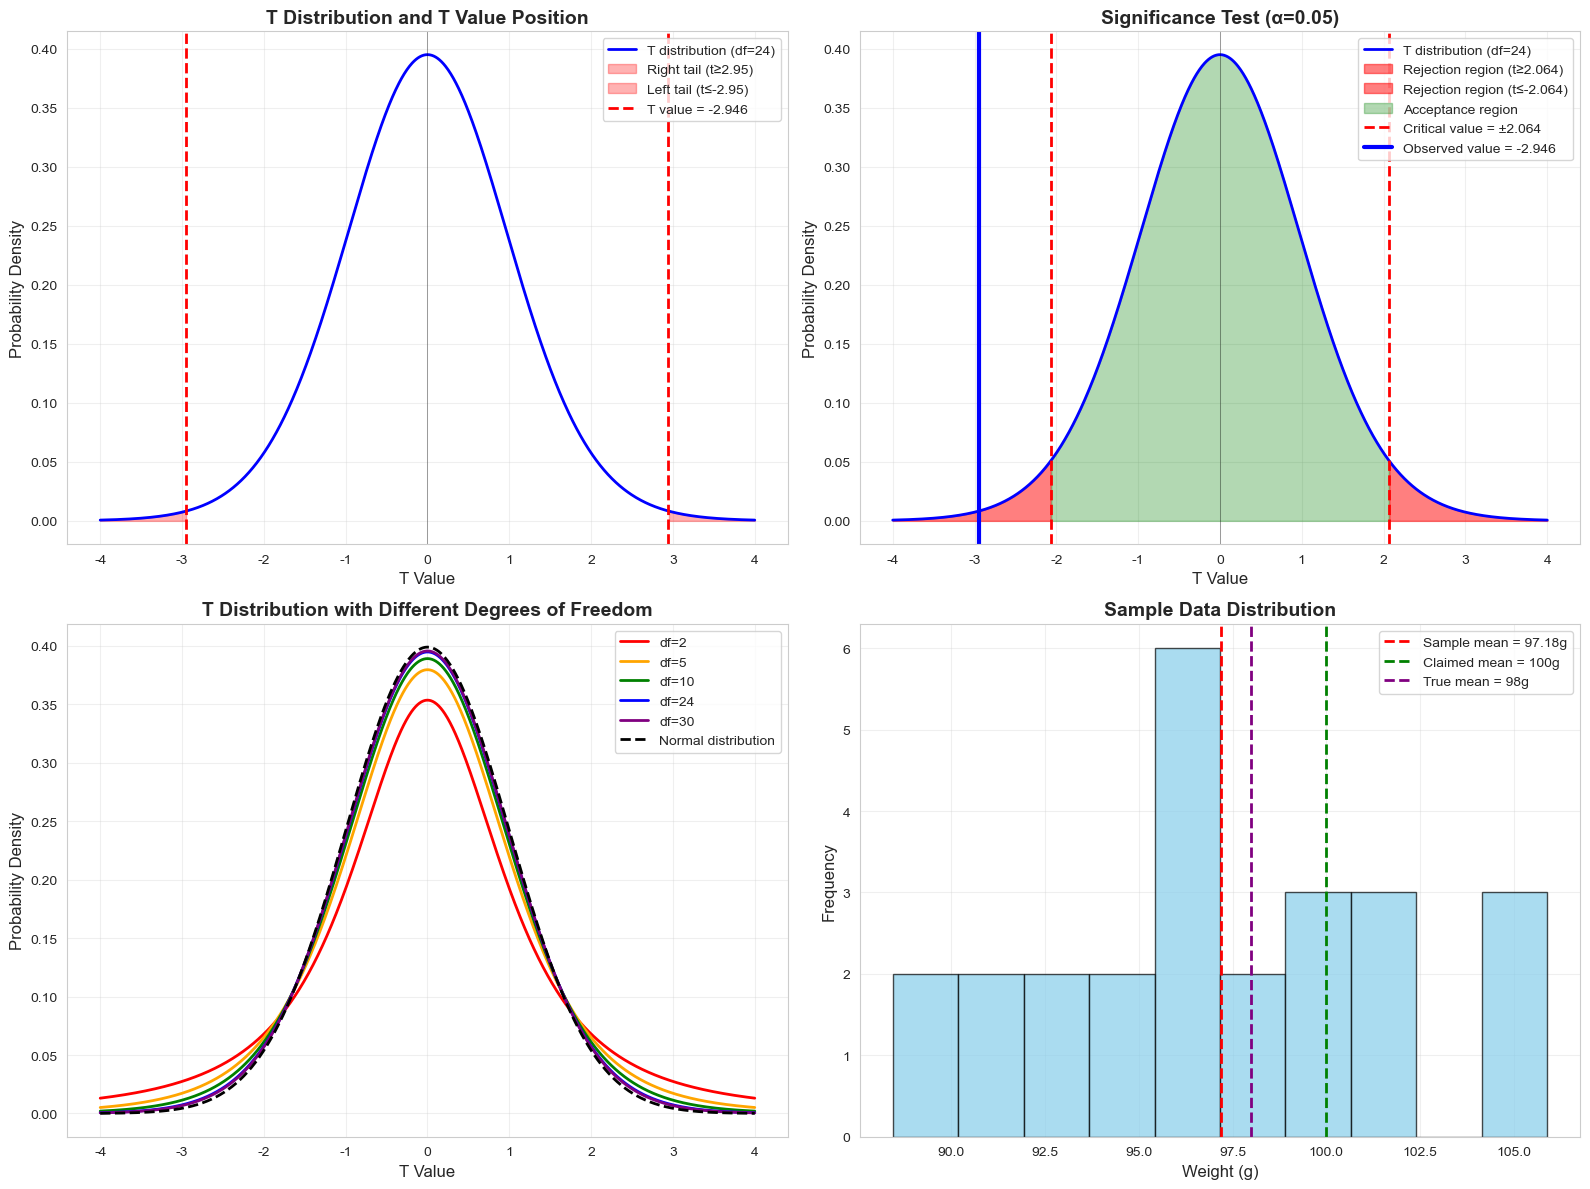


📊 Visualization Description:
  Figure 1: T distribution curve and our T value position
  Figure 2: Rejection and acceptance regions (critical value = ±2.064)
  Figure 3: Shape changes of T distribution with different degrees of freedom
  Figure 4: Actual sample data distribution


In [11]:
# Create T distribution visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ========== Figure 1: T Distribution Curve and T Value Position ==========
ax1 = axes[0, 0]
x = np.linspace(-4, 4, 1000)
t_dist = stats.t.pdf(x, df=degrees_of_freedom)

ax1.plot(x, t_dist, 'b-', linewidth=2, label=f'T distribution (df={degrees_of_freedom})')
ax1.fill_between(x, t_dist, where=(x >= abs(t_statistic)), 
                  color='red', alpha=0.3, label=f'Right tail (t≥{abs(t_statistic):.2f})')
ax1.fill_between(x, t_dist, where=(x <= -abs(t_statistic)), 
                  color='red', alpha=0.3, label=f'Left tail (t≤{-abs(t_statistic):.2f})')

# Mark T value position
ax1.axvline(x=t_statistic, color='red', linestyle='--', linewidth=2, 
            label=f'T value = {t_statistic:.3f}')
ax1.axvline(x=-t_statistic, color='red', linestyle='--', linewidth=2)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

ax1.set_xlabel('T Value', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.set_title('T Distribution and T Value Position', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# ========== Figure 2: Critical Value Regions ==========
ax2 = axes[0, 1]
critical_value = stats.t.ppf(1 - alpha/2, df=degrees_of_freedom)

ax2.plot(x, t_dist, 'b-', linewidth=2, label=f'T distribution (df={degrees_of_freedom})')
ax2.fill_between(x, t_dist, where=(x >= critical_value), 
                  color='red', alpha=0.5, label=f'Rejection region (t≥{critical_value:.3f})')
ax2.fill_between(x, t_dist, where=(x <= -critical_value), 
                  color='red', alpha=0.5, label=f'Rejection region (t≤{-critical_value:.3f})')
ax2.fill_between(x, t_dist, where=(np.abs(x) < critical_value), 
                  color='green', alpha=0.3, label='Acceptance region')

# Mark critical values and T value
ax2.axvline(x=critical_value, color='red', linestyle='--', linewidth=2, 
            label=f'Critical value = ±{critical_value:.3f}')
ax2.axvline(x=-critical_value, color='red', linestyle='--', linewidth=2)
ax2.axvline(x=t_statistic, color='blue', linestyle='-', linewidth=3, 
            label=f'Observed value = {t_statistic:.3f}')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

ax2.set_xlabel('T Value', fontsize=12)
ax2.set_ylabel('Probability Density', fontsize=12)
ax2.set_title(f'Significance Test (α={alpha})', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# ========== Figure 3: T Distribution Comparison Across Different Degrees of Freedom ==========
ax3 = axes[1, 0]
df_list = [2, 5, 10, degrees_of_freedom, 30]
colors = ['red', 'orange', 'green', 'blue', 'purple']

for df, color in zip(df_list, colors):
    t_dist_df = stats.t.pdf(x, df=df)
    ax3.plot(x, t_dist_df, color=color, linewidth=2, label=f'df={df}')

# Standard normal distribution
norm_dist = stats.norm.pdf(x, 0, 1)
ax3.plot(x, norm_dist, 'k--', linewidth=2, label='Normal distribution')

ax3.set_xlabel('T Value', fontsize=12)
ax3.set_ylabel('Probability Density', fontsize=12)
ax3.set_title('T Distribution with Different Degrees of Freedom', fontsize=14, fontweight='bold')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# ========== Figure 4: Sample Data Distribution ==========
ax4 = axes[1, 1]
ax4.hist(sample, bins=10, edgecolor='black', alpha=0.7, color='skyblue')
ax4.axvline(x=sample_mean, color='red', linestyle='--', linewidth=2, 
            label=f'Sample mean = {sample_mean:.2f}g')
ax4.axvline(x=claimed_mean, color='green', linestyle='--', linewidth=2, 
            label=f'Claimed mean = {claimed_mean}g')
ax4.axvline(x=true_mean, color='purple', linestyle='--', linewidth=2, 
            label=f'True mean = {true_mean}g')

ax4.set_xlabel('Weight (g)', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title('Sample Data Distribution', fontsize=14, fontweight='bold')
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Visualization Description:")
print(f"  Figure 1: T distribution curve and our T value position")
print(f"  Figure 2: Rejection and acceptance regions (critical value = ±{critical_value:.3f})")
print(f"  Figure 3: Shape changes of T distribution with different degrees of freedom")
print(f"  Figure 4: Actual sample data distribution")

## 6. 计算置信区间

In [12]:
# 计算 95% 置信区间
confidence_level = 0.95
t_critical = stats.t.ppf(1 - (1 - confidence_level)/2, df=degrees_of_freedom)
margin_of_error = t_critical * standard_error
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print("📊 95% 置信区间:")
print(f"\n计算步骤:")
print(f"  1. T 临界值 (df={degrees_of_freedom}, 95%) = {t_critical:.4f}")
print(f"  2. 误差范围 = {t_critical:.4f} × {standard_error:.4f} = {margin_of_error:.4f}")
print(f"  3. 置信区间 = [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\n💡 置信区间的含义:")
print(f"     我们有 95% 的信心，真实的总体Mean在 {ci_lower:.2f}g 到 {ci_upper:.2f}g 之间")
print(f"\n🎯 与假设检验的关系:")
if claimed_mean < ci_lower or claimed_mean > ci_upper:
    print(f"  ✓ 假设值 {claimed_mean}g 不在置信区间内")
    print(f"  ✓ 这与 P 值检验结果一致（拒绝原假设）")
else:
    print(f"  ✗ 假设值 {claimed_mean}g 在置信区间内")
    print(f"  ✗ 这与 P 值检验结果一致（不能拒绝原假设）")

📊 95% 置信区间:

计算步骤:
  1. T 临界值 (df=24, 95%) = 2.0639
  2. 误差范围 = 2.0639 × 0.9566 = 1.9742
  3. 置信区间 = [95.2082, 99.1567]

💡 置信区间的含义:
     我们有 95% 的信心，真实的总体均值在 95.21g 到 99.16g 之间

🎯 与假设检验的关系:
  ✓ 假设值 100g 不在置信区间内
  ✓ 这与 P 值检验结果一致（拒绝原假设）


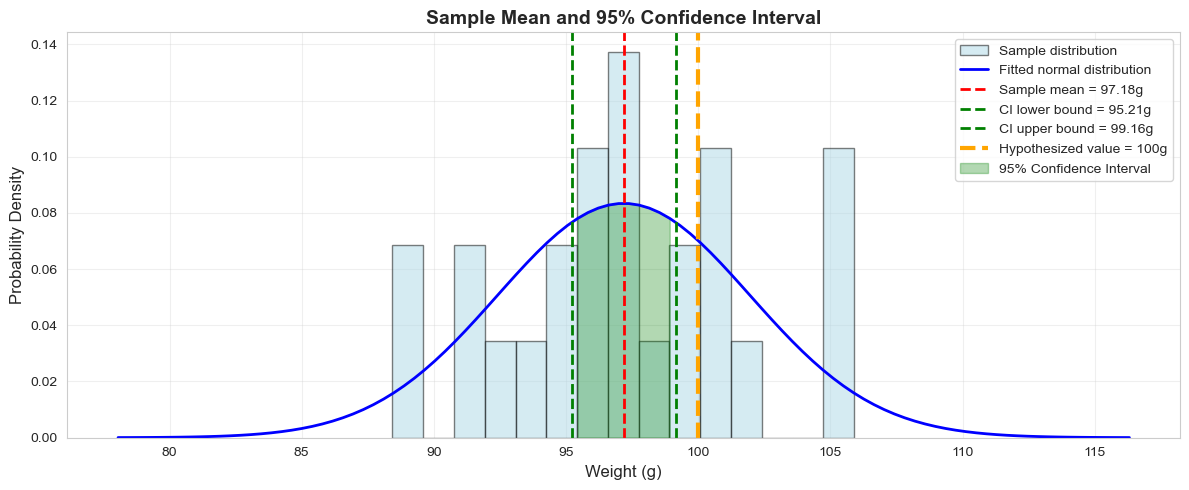

In [13]:
# Visualize confidence interval
fig, ax = plt.subplots(figsize=(12, 5))

# Plot sample distribution
ax.hist(sample, bins=15, edgecolor='black', alpha=0.5, color='lightblue', 
        density=True, label='Sample distribution')

# Plot normal distribution curve
x_norm = np.linspace(sample_mean - 4*sample_std, sample_mean + 4*sample_std, 100)
y_norm = stats.norm.pdf(x_norm, sample_mean, sample_std)
ax.plot(x_norm, y_norm, 'b-', linewidth=2, label='Fitted normal distribution')

# Mark confidence interval
ax.axvline(x=sample_mean, color='red', linestyle='--', linewidth=2, 
            label=f'Sample mean = {sample_mean:.2f}g')
ax.axvline(x=ci_lower, color='green', linestyle='--', linewidth=2, 
            label=f'CI lower bound = {ci_lower:.2f}g')
ax.axvline(x=ci_upper, color='green', linestyle='--', linewidth=2, 
            label=f'CI upper bound = {ci_upper:.2f}g')
ax.axvline(x=claimed_mean, color='orange', linestyle='--', linewidth=3, 
            label=f'Hypothesized value = {claimed_mean}g')

# Fill confidence interval region
ax.fill_between(x_norm, y_norm, where=((x_norm >= ci_lower) & (x_norm <= ci_upper)),
                 color='green', alpha=0.3, label='95% Confidence Interval')

ax.set_xlabel('Weight (g)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(f'Sample Mean and 95% Confidence Interval', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 效应量 (Effect Size)

In [14]:
# 计算 Cohen's d (效应量)
cohens_d = (sample_mean - claimed_mean) / sample_std

print("📊 效应量 (Cohen's d):")
print(f"\n计算公式: d = (样本Mean - 假设Mean) / 样本标准差")
print(f"实际计算: d = ({sample_mean:.4f} - {claimed_mean}) / {sample_std:.4f}")
print(f"          = {cohens_d:.4f}")
print(f"\n💡 Cohen's d 的含义: 差异的标准化度量")
print(f"\n🎯 Cohen's d 的解释标准:")
print(f"  |d| < 0.2: 效应量极小 (negligible)")
print(f"  0.2 ≤ |d| < 0.5: 效应量小 (small)")
print(f"  0.5 ≤ |d| < 0.8: 效应量中等 (medium)")
print(f"  |d| ≥ 0.8: 效应量大 (large)")
print(f"\n当前结果: |d| = {abs(cohens_d):.4f}", end="")
if abs(cohens_d) < 0.2:
    print(" → 效应量极小")
elif abs(cohens_d) < 0.5:
    print(" → 效应量小")
elif abs(cohens_d) < 0.8:
    print(" → 效应量中等")
else:
    print(" → 效应量大")

📊 效应量 (Cohen's d):

计算公式: d = (样本均值 - 假设均值) / 样本标准差
实际计算: d = (97.1825 - 100) / 4.7828
          = -0.5891

💡 Cohen's d 的含义: 差异的标准化度量

🎯 Cohen's d 的解释标准:
  |d| < 0.2: 效应量极小 (negligible)
  0.2 ≤ |d| < 0.5: 效应量小 (small)
  0.5 ≤ |d| < 0.8: 效应量中等 (medium)
  |d| ≥ 0.8: 效应量大 (large)

当前结果: |d| = 0.5891 → 效应量中等


## 8. 不同样本量下的 T 检验对比

In [15]:
# Simulate T tests with different sample sizes
sample_sizes = [5, 10, 20, 30, 50, 100]
results = []

for n_test in sample_sizes:
    # Generate new sample
    sample_test = np.random.normal(true_mean, true_std, n_test)
    
    # Calculate T statistic and P value
    t_stat_test, p_value_test = stats.ttest_1samp(sample_test, claimed_mean)
    df_test = n_test - 1
    
    results.append({
        'Sample Size': n_test,
        'Degrees of Freedom': df_test,
        'T Statistic': t_stat_test,
        'P Value': p_value_test,
        'Significant': p_value_test < 0.05,
        'Sample Mean': np.mean(sample_test)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

print("📊 T test results with different sample sizes:")
print(results_df.to_string(index=False))

print(f"\n💡 Key observations:")
print(f"  1. Larger sample size → larger degrees of freedom")
print(f"  2. Larger sample size → smaller standard error → potentially larger T statistic")
print(f"  3. Larger sample size → typically smaller P value (easier to achieve significance)")
print(f"  4. But small samples can also be significant (if the difference is large)")

📊 T test results with different sample sizes:
 Sample Size  Degrees of Freedom  T Statistic  P Value  Significant  Sample Mean
           5                   4    -2.651541 0.056890        False    96.443295
          10                   9    -1.960781 0.081542        False    96.449467
          20                  19    -2.324691 0.031324         True    97.866548
          30                  29    -2.137453 0.041121         True    98.064424
          50                  49    -3.345668 0.001582         True    97.712873
         100                  99    -2.876011 0.004932         True    98.559372

💡 Key observations:
  1. Larger sample size → larger degrees of freedom
  2. Larger sample size → smaller standard error → potentially larger T statistic
  3. Larger sample size → typically smaller P value (easier to achieve significance)
  4. But small samples can also be significant (if the difference is large)


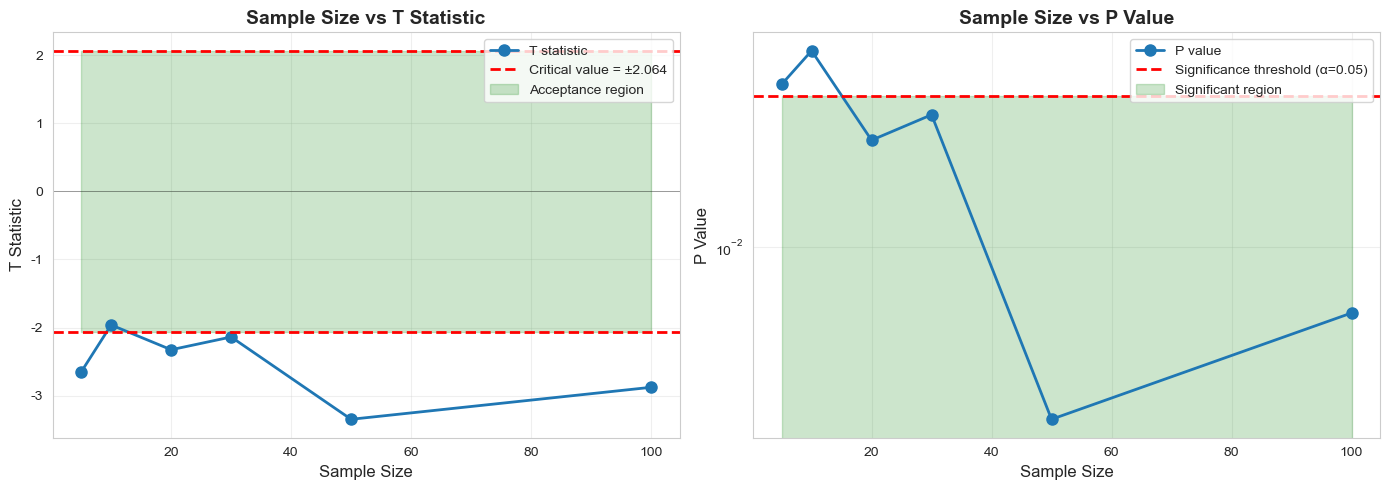

In [16]:
# Visualize results with different sample sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Figure 1: T statistic vs sample size
axes[0].plot(results_df['Sample Size'], results_df['T Statistic'], 'o-', 
             linewidth=2, markersize=8, label='T statistic')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
axes[0].axhline(y=critical_value, color='red', linestyle='--', linewidth=2, 
            label=f'Critical value = ±{critical_value:.3f}')
axes[0].axhline(y=-critical_value, color='red', linestyle='--', linewidth=2)
axes[0].fill_between(results_df['Sample Size'], critical_value, -critical_value, 
                     color='green', alpha=0.2, label='Acceptance region')
axes[0].set_xlabel('Sample Size', fontsize=12)
axes[0].set_ylabel('T Statistic', fontsize=12)
axes[0].set_title('Sample Size vs T Statistic', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Figure 2: P value vs sample size
colors = ['red' if p >= 0.05 else 'green' for p in results_df['P Value']]
axes[1].plot(results_df['Sample Size'], results_df['P Value'], 'o-', 
             linewidth=2, markersize=8, label='P value')
axes[1].axhline(y=0.05, color='red', linestyle='--', linewidth=2, 
            label='Significance threshold (α=0.05)')
axes[1].fill_between(results_df['Sample Size'], 0, 0.05, 
                     color='green', alpha=0.2, label='Significant region')
axes[1].set_xlabel('Sample Size', fontsize=12)
axes[1].set_ylabel('P Value', fontsize=12)
axes[1].set_title('Sample Size vs P Value', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')  # Use logarithmic scale

plt.tight_layout()
plt.show()

## 9. 总结报告

In [17]:
print("=" * 60)
print("📋 T 检验完整报告")
print("=" * 60)
print(f"\n🎯 研究问题:")
print(f"   公司声称薯片平均重量为 {claimed_mean}g，是否准确？")
print(f"\n📊 数据概况:")
print(f"   样本量: {n}")
print(f"   样本Mean: {sample_mean:.4f} g")
print(f"   样本标准差: {sample_std:.4f} g")
print(f"   标准误: {standard_error:.4f} g")
print(f"\n🧮 统计检验:")
print(f"   检验类型: 单样本 T 检验（双尾）")
print(f"   自由度: {degrees_of_freedom}")
print(f"   T 统计量: {t_statistic:.4f}")
print(f"   P 值: {p_value:.6f}")
print(f"   临界值 (α=0.05): ±{critical_value:.4f}")
print(f"\n📈 效应量:")
print(f"   Cohen's d: {cohens_d:.4f}")
print(f"\n📏 置信区间 (95%):")
print(f"   [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\n🎯 结论:")
if is_significant:
    print(f"   ✓ P = {p_value:.6f} < 0.05")
    print(f"   ✓ 拒绝原假设")
    print(f"   ✓ 样本Mean与 {claimed_mean}g 有显著差异")
    print(f"   ✓ 公司声称不准确！")
else:
    print(f"   ✗ P = {p_value:.6f} ≥ 0.05")
    print(f"   ✗ 不能拒绝原假设")
    print(f"   ✗ 没有足够证据表明差异显著")
    print(f"   ✗ 公司声称可能是正确的")
print(f"\n💡 实际情况:")
print(f"   真实Mean: {true_mean} g")
print(f"   真实差异: {abs(true_mean - claimed_mean)} g")
print(f"   我们的检验结论: {'正确' if (is_significant and true_mean != claimed_mean) or (not is_significant and true_mean == claimed_mean) else '错误'}")
print("\n" + "=" * 60)

📋 T 检验完整报告

🎯 研究问题:
   公司声称薯片平均重量为 100g，是否准确？

📊 数据概况:
   样本量: 25
   样本均值: 97.1825 g
   样本标准差: 4.7828 g
   标准误: 0.9566 g

🧮 统计检验:
   检验类型: 单样本 T 检验（双尾）
   自由度: 24
   T 统计量: -2.9455
   P 值: 0.007061
   临界值 (α=0.05): ±2.0639

📈 效应量:
   Cohen's d: -0.5891

📏 置信区间 (95%):
   [95.2082, 99.1567]

🎯 结论:
   ✓ P = 0.007061 < 0.05
   ✓ 拒绝原假设
   ✓ 样本均值与 100g 有显著差异
   ✓ 公司声称不准确！

💡 实际情况:
   真实均值: 98 g
   真实差异: 2 g
   我们的检验结论: 正确



## 10. 核心概念回顾

### 📌 自由度 (Degrees of Freedom, df)
- **定义**: 可以自由变化的数值个数
- **公式**: df = n - 1（单样本 T 检验）
- **含义**: 反映信息的丰富程度
- **影响**: df 越小 → T 分布越扁平 → 越难达到显著

### 📌 T 分布
- **定义**: 当总体标准差未知时使用的概率分布
- **特点**: 比正态分布更扁平，尾部更厚
- **原因**: 用样本标准差代替总体标准差，增加不确定性
- **性质**: df → ∞ 时，T 分布 → 正态分布

### 📌 P 值
- **定义**: 在原假设为真时，获得当前或更极端结果的概率
- **含义**: 偶然造成当前差异的可能性
- **解释**: P = 0.03 表示 "如果原假设为真，出现这种差异的概率只有 3%"

### 📌 0.05 阈值
- **历史**: 1925 年 Ronald Fisher 提出
- **含义**: 愿意承担 5% 的错误风险
- **注意**: 不是魔法数字，可以根据实际情况调整
- **权衡**: 降低 α（更严格）→ 增加第二类错误风险

### 🔗 三者关系
```
样本量 n
    ↓
自由度 df = n - 1
    ↓
T 分布形状（df 越小，越扁平）
    ↓
T 值对应的 P 值
    ↓
与 0.05 比较 → 显著性判断
```

### 💡 关键理解
- 小样本 → 小自由度 → T 分布扁平 → 需要大 T 值 → 难显著
- 大样本 → 大自由度 → T 分布接近正态 → 小 T 值即可 → 易显著
- P 值越小，证据越强
- 显著性 ≠ 重要性（需要看效应量）

## 11. 常见误区提醒

### ❌ 误区 1: P < 0.05 就意味着原假设一定错误
**✓ 正确理解**: P < 0.05 只是说明在原假设下出现这种结果的概率很小，但不是不可能

### ❌ 误区 2: P > 0.05 就证明原假设正确
**✓ 正确理解**: P > 0.05 只是说没有足够证据拒绝原假设，不代表原假设正确

### ❌ 误区 3: P 值越小，效应越大
**✓ 正确理解**: P 值受样本量影响，大样本下小差异也可能显著。应该看效应量（Cohen's d）

### ❌ 误区 4: 0.05 是绝对标准
**✓ 正确理解**: 0.05 是约定俗成的标准，不是科学真理。不同领域可能使用不同阈值

### ❌ 误区 5: T 检验只看 P 值
**✓ 正确理解**: 应该综合看 P 值、效应量、置信区间和实际意义